In [24]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv3D, MaxPooling3D, concatenate, 
    Conv3DTranspose, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from scipy.ndimage import rotate
from tensorflow import keras
import segmentation_models_3D as sm
import pandas as pd
import time
from medpy.metric.binary import hd95
import psutil
from datetime import datetime



# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

################################################################
# Model Architecture
################################################################

def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS, num_classes):
    """3D U-Net model for brain tumor segmentation"""
    kernel_initializer = 'he_uniform'
    
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS))
    s = inputs

    # Contraction path
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c1)
    p1 = MaxPooling3D((2, 2, 2))(c1)

    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c2)
    p2 = MaxPooling3D((2, 2, 2))(c2)

    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c3)
    p3 = MaxPooling3D((2, 2, 2))(c3)

    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c4)
    p4 = MaxPooling3D(pool_size=(2, 2, 2))(c4)

    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c5)

    # Expansive path
    u6 = Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c6)

    u7 = Conv3DTranspose(64, (2, 2, 2), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c7)

    u8 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c8)

    u9 = Conv3DTranspose(16, (2, 2, 2), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c9)

    outputs = Conv3D(num_classes, (1, 1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

In [25]:
def extract_patch(image, mask, patch_size):
    """Extract random patch from image and mask"""
    img_shape = image.shape[:3]
    patch_x = np.random.randint(0, max(img_shape[0] - patch_size[0], 1))
    patch_y = np.random.randint(0, max(img_shape[1] - patch_size[1], 1))
    patch_z = np.random.randint(0, max(img_shape[2] - patch_size[2], 1))

    return (
        image[patch_x:patch_x + patch_size[0], patch_y:patch_y + patch_size[1], patch_z:patch_z + patch_size[2], :],
        mask[patch_x:patch_x + patch_size[0], patch_y:patch_y + patch_size[1], patch_z:patch_z + patch_size[2]]
    )

In [26]:
def gamma_correction(image, gamma):
    """Apply gamma correction to image"""
    return np.clip(image ** gamma, 0, 1)

def augment_image(image, mask, is_training=True):
    """Apply random augmentations to image and mask"""
    if is_training:
        # Rotation
        angle = np.random.uniform(-15, 15)
        image = rotate(image, angle, axes=(0, 1), reshape=False, mode='reflect')
        mask = rotate(mask, angle, axes=(0, 1), reshape=False, mode='reflect')

        # Flipping
        if np.random.rand() > 0.5:
            image, mask = np.flip(image, axis=0), np.flip(mask, axis=0)
        if np.random.rand() > 0.5:
            image, mask = np.flip(image, axis=1), np.flip(mask, axis=1)

        # Brightness Adjustment
        brightness = np.random.uniform(0.9, 1.1)
        image = np.clip(image * brightness, 0, 1)

        # Noise Addition (Gaussian noise)
        if np.random.rand() > 0.5:
            noise = np.random.normal(0, 0.02, image.shape)
            image = np.clip(image + noise, 0, 1)

        # Gamma Correction
        if np.random.rand() > 0.5:
            gamma = np.random.uniform(0.8, 1.2)
            image = gamma_correction(image, gamma)

    return image, mask

In [27]:
def load_img(img_dir, img_list):
    """Load numpy images from directory"""
    images = []
    for image_name in img_list:
        if image_name.endswith('.npy'):
            try:
                image = np.load(os.path.join(img_dir, image_name), allow_pickle=True).astype(np.float32)
                images.append(image)
            except Exception as e:
                print(f"Error loading file {image_name}: {e}")
    return np.array(images) if images else np.array([])


def imageLoader(img_dir, img_list, mask_dir, mask_list, batch_size, patch_size, is_training=True):
    """Generator for loading and augmenting image patches"""
    L = len(img_list)
    while True:
        batch_start = 0
        while batch_start < L:
            batch_end = min(batch_start + batch_size, L)
            X = load_img(img_dir, img_list[batch_start:batch_end])
            Y = load_img(mask_dir, mask_list[batch_start:batch_end])

            if len(X) == 0 or len(Y) == 0:
                batch_start = batch_end
                continue

            # Convert masks to one-hot if they aren't already
            if len(Y.shape) == 4:  # Assuming shape [batch, H, W, D]
                Y = tf.one_hot(Y.astype(np.int32), depth=4)  # Convert to one-hot
            
            X_patches, Y_patches = zip(*[augment_image(*extract_patch(img, mask, patch_size), is_training)
                                       for img, mask in zip(X, Y)])

            yield np.stack(X_patches, axis=0), np.stack(Y_patches, axis=0)
            batch_start = batch_end

In [28]:
import numpy as np
import os
from scipy.ndimage import rotate

import tensorflow as tf


# DICE SCORE CUSTOM FUNCTION 
class DiceScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, class_weights=None, smooth=1e-6, **kwargs):
        super(DiceScore, self).__init__(**kwargs)
        self.num_classes = num_classes
        self.smooth = smooth
        self.class_weights = class_weights if class_weights is not None else tf.ones(num_classes)  # Default to equal weights
        self.dice_scores = self.add_weight(name='dice_scores', shape=(self.num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Flatten the tensors to ensure computations are class-wise
        y_true = tf.reshape(y_true, [-1])  # Flatten ground truth
        y_pred = tf.reshape(y_pred, [-1])  # Flatten predictions

        # Initialize the dice scores for each class
        dice_scores = []

        for i in range(self.num_classes):
            # Create binary masks for class i
            y_true_class = tf.cast(tf.equal(y_true, i), 'float32')
            y_pred_class = tf.cast(tf.equal(tf.round(y_pred), i), 'float32')

            # Calculate intersection and union
            intersection = tf.reduce_sum(y_true_class * y_pred_class)
            union = tf.reduce_sum(y_true_class) + tf.reduce_sum(y_pred_class)

            # Compute Dice score for the current class
            dice_class = (2. * intersection + self.smooth) / (union + self.smooth)

            # Apply class weight to the Dice score
            weighted_dice_class = dice_class * self.class_weights[i]
            dice_scores.append(weighted_dice_class)

        # Update state by averaging weighted dice scores across all classes
        dice_scores = tf.stack(dice_scores)
        self.dice_scores.assign(dice_scores)

    def result(self):
        # Return the mean of the weighted dice scores
        return tf.reduce_mean(self.dice_scores)

    def reset_states(self):
        # Reset the dice scores at the start of each batch
        self.dice_scores.assign(tf.zeros(self.num_classes))

In [29]:
import time
import segmentation_models_3D as sm
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os
import pandas as pd

# MODEL TRAINING 
import time

start = time.time()
# Set up loss function with class weights
wt0, wt1, wt2, wt3 = 0.25, 0.25, 0.25, 0.25
class_weights = np.array([wt0, wt1, wt2, wt3], dtype=np.float32)

dice_loss = sm.losses.DiceLoss(class_weights=class_weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = 0.2 * dice_loss + 0.2 * focal_loss  # focal loss of 0.2 (perf best now) becomes 0.1

# Define metrics
metrics = ['accuracy', sm.metrics.IOUScore(threshold=0.5), DiceScore(num_classes=4)]

# Learning rate scheduler (Cosine Decay)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5 # from 6 to 4(perf better) to 3
)

# Optimizer (use a fixed learning rate)
optimizer = keras.optimizers.Nadam(learning_rate=0.001, clipnorm=1.0) #increase from 0.001(perf best) to 0.01

# Data paths
DATA_ROOT = "glioma split data"
train_img_dir, train_mask_dir = f"{DATA_ROOT}/train/images/", f"{DATA_ROOT}/train/masks/"
val_img_dir, val_mask_dir = f"{DATA_ROOT}/val/images/", f"{DATA_ROOT}/val/masks/"

# Load data
train_img_list, train_mask_list = os.listdir(train_img_dir), os.listdir(train_mask_dir)
val_img_list, val_mask_list = os.listdir(val_img_dir), os.listdir(val_mask_dir)

# Data generators
batch_size = 2
patch_size = (64, 64, 64)
train_data = imageLoader(train_img_dir, train_img_list, train_mask_dir, train_mask_list, batch_size, patch_size)
val_data = imageLoader(val_img_dir, val_img_list, val_mask_dir, val_mask_list, batch_size, patch_size)

# Training parameters
steps_per_epoch = len(train_img_list) // batch_size
val_steps_per_epoch = len(val_img_list) // batch_size
epochs = 100

# Initialize and compile model
model = simple_unet_model(IMG_HEIGHT=64, IMG_WIDTH=64, IMG_DEPTH=64, IMG_CHANNELS=4, num_classes=4)
model.compile(optimizer=optimizer, loss=total_loss, metrics=metrics)
model.summary()

# Define callbacks
checkpoint_path = f"saved_model/3D_unet_{epochs}_epochs_{batch_size}_batch_patch_training.keras"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), #increase patience from 10 to 20
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min'),
    lr_scheduler  # Learning rate decay callback
]

# Train model
history = model.fit(
    train_data,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=val_data,
    validation_steps=val_steps_per_epoch,
    callbacks=callbacks,
    verbose=1
)

# Save training history
history_df = pd.DataFrame(history.history)
os.makedirs("model_history", exist_ok=True)
history_df.to_csv("model_history/training_history.csv", index=False)
print("Training history and best model saved successfully.")

end = time.time()
exec_time = (end - start)/60
print(f'execution time is - {exec_time}')


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 64, 64,    │      1,744 │ input_layer[0][0] │
│                     │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ conv3d[0][0]      │
│                     │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 64, 64,    │      6,928 │ dropout[0][0]     │
│                     │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 32, 32,    │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 32, 32,    │     13,856 │ max_pooling3d[0]… │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ conv3d_2[0][0]    │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 32, 32,    │     27,680 │ dropout_1[0][0]   │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 16, 16,    │          0 │ conv3d_3[0][0]    │
│ (MaxPooling3D)      │ 16, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 16, 16,    │     55,360 │ max_pooling3d_1[… │
│                     │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ conv3d_4[0][0]    │
│                     │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 16, 16,    │    110,656 │ dropout_2[0][0]   │
│                     │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 8, 8, 8,   │          0 │ conv3d_5[0][0]    │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 8, 8, 8,   │    221,312 │ max_pooling3d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 8,   │          0 │ conv3d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_7 (Conv3D)   │ (None, 8, 8, 8,   │    442,496 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_3     │ (None, 4, 4, 4,   │          0 │ conv3d_7[0][0]  

 Total params: 5,646,260 (21.54 MB)

 Trainable params: 5,646,260 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 397s 11s/step - accuracy: 0.7025 - dice_score_3: 0.8063 - iou_score: 0.1203 - loss: 0.1965 - val_accuracy: 0.8890 - val_dice_score_3: 0.9063 - val_iou_score: 0.2577 - val_loss: 0.1915 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 308s 9s/step - accuracy: 0.8225 - dice_score_3: 0.8709 - iou_score: 0.2289 - loss: 0.1945 - val_accuracy: 0.8584 - val_dice_score_3: 0.8267 - val_iou_score: 0.2816 - val_loss: 0.1925 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 296s 9s/step - accuracy: 0.7847 - dice_score_3: 0.8394 - iou_score: 0.1871 - loss: 0.1933 - val_accuracy: 0.8884 - val_dice_score_3: 0.9645 - val_iou_score: 0.3987 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 312s 9s/step - accuracy: 0.8017 - dice_score_3: 0.8565 - iou_score: 0.2189 - loss: 0.1932 - val_accuracy: 0.8552 - val_dice_score_3: 0.9659 - val_iou_score: 0.2492 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 5/100
33/

In [35]:
import os
import numpy as np
import keras
from keras.models import load_model
from keras.metrics import MeanIoU
from matplotlib import pyplot as plt

# -------------------- MODEL LOADING --------------------
# Path to trained model
model_path = 'saved_model/3D_unet_100_epochs_2_batch_patch_training.keras'

# Load the trained model without recompiling (for inference only)
my_model = load_model(model_path, compile=False)

# -------------------- DATA LOADING --------------------
# Path to dataset (Modify as needed)
DATA_PATH = "glioma split data"

# Train and Validation Directories
train_img_dir = os.path.join(DATA_PATH, "train/images/")
train_mask_dir = os.path.join(DATA_PATH, "train/masks/")
val_img_dir = os.path.join(DATA_PATH, "val/images/")
val_mask_dir = os.path.join(DATA_PATH, "val/masks/")
test_img_dir = os.path.join(DATA_PATH, "test/images/")
test_mask_dir = os.path.join(DATA_PATH, "test/masks/")

# Get list of images and masks
train_img_list, train_mask_list = os.listdir(train_img_dir), os.listdir(train_mask_dir)
val_img_list, val_mask_list = os.listdir(val_img_dir), os.listdir(val_mask_dir)
test_img_list, test_mask_list = os.listdir(test_img_dir), os.listdir(test_mask_dir)

# Define patch and batch size
patch_size = (64, 64, 64)
batch_size = 2

# -------------------- VALIDATION DATA EVALUATION --------------------
# Create Data Generator for validation set
val_img_loader = imageLoader(val_img_dir, val_img_list, val_mask_dir, val_mask_list, batch_size, patch_size)

# Fetch a batch for evaluation
val_img_batch, val_mask_batch = val_img_loader.__next__()

# Convert masks to argmax format
val_mask_argmax = np.argmax(val_mask_batch, axis=4)

# Model prediction
val_pred_batch = my_model.predict(val_img_batch)
val_pred_argmax = np.argmax(val_pred_batch, axis=4)

# Compute Mean IoU
#sm.metrics.IOUScore(threshold=0.5)
n_classes = 4
iou_metric = MeanIoU(num_classes=n_classes)
iou_metric.update_state(val_pred_argmax, val_mask_argmax)
val_iou_score = iou_metric.result().numpy()

# Compute Dice Score
dice_metric = DiceScore(num_classes=n_classes)
dice_metric.update_state(val_mask_argmax, val_pred_argmax)
val_dice_score = dice_metric.result().numpy()

print(f"Validation Mean IoU: {val_iou_score}")
print(f"Validation Dice Score: {val_dice_score}")

# -------------------- TEST DATA EVALUATION --------------------
# Create Data Generator for test set
test_img_loader = imageLoader(test_img_dir, test_img_list, test_mask_dir, test_mask_list, batch_size, patch_size)

# Fetch a batch for evaluation
test_img_batch, test_mask_batch = test_img_loader.__next__()

# Convert masks to argmax format
test_mask_argmax = np.argmax(test_mask_batch, axis=4)

# Model prediction
test_pred_batch = my_model.predict(test_img_batch)
test_pred_argmax = np.argmax(test_pred_batch, axis=4)

# Compute Mean IoU
iou_metric.update_state(test_pred_argmax, test_mask_argmax)
test_iou_score = iou_metric.result().numpy()

# Compute Dice Score
dice_metric.update_state(test_mask_argmax, test_pred_argmax)
test_dice_score = dice_metric.result().numpy()

print(f"Test Mean IoU: {test_iou_score}")
print(f"Test Dice Score: {test_dice_score}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Validation Mean IoU: 0.18358850479125977
Validation Dice Score: 0.2117082178592682
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Test Mean IoU: 0.20645403861999512
Test Dice Score: 0.23921366035938263


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


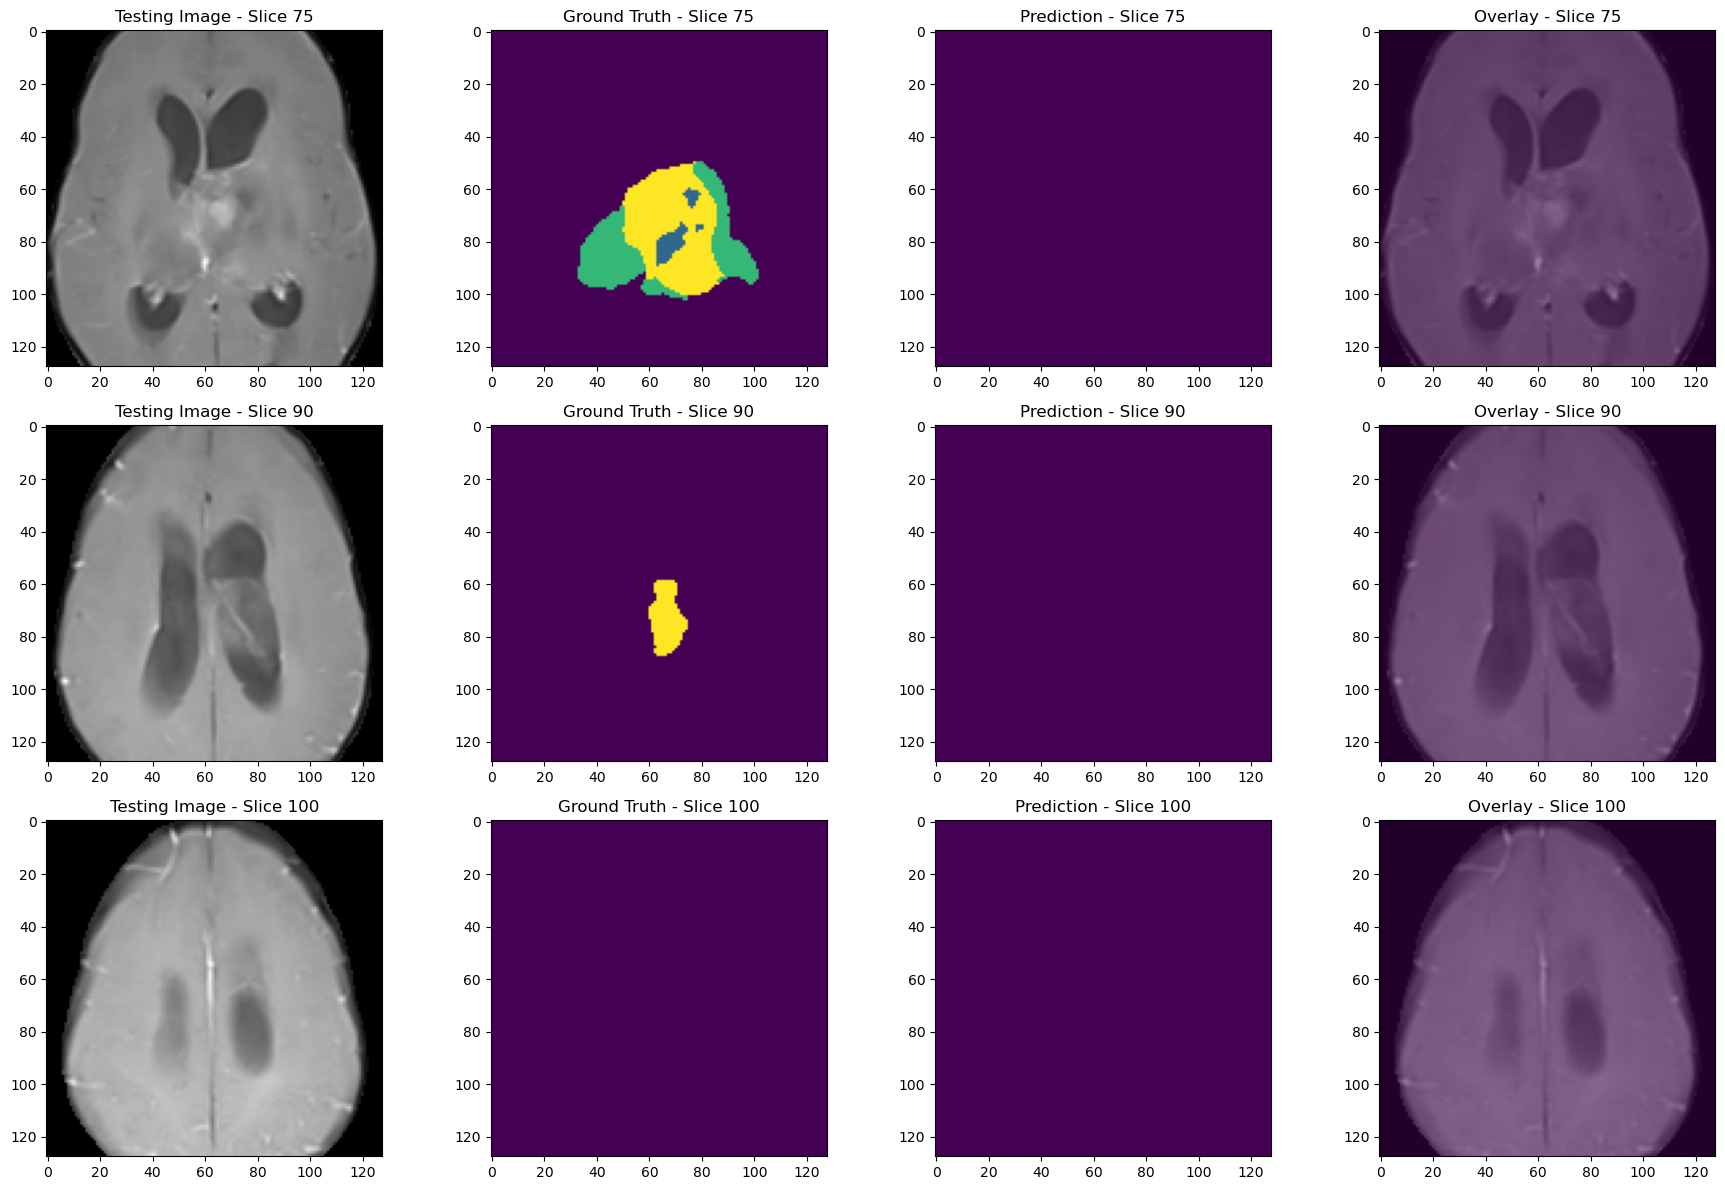

In [39]:
img_num = 21  # Change index as needed
test_img = np.load(os.path.join(test_img_dir, f"image_{img_num}.npy"))
test_mask = np.load(os.path.join(test_mask_dir, f"mask_{img_num}.npy"))
test_mask_argmax = np.argmax(test_mask, axis=3)

# Expand dimensions for model prediction
test_img_input = np.expand_dims(test_img, axis=0)
test_prediction = my_model.predict(test_img_input)
test_prediction_argmax = np.argmax(test_prediction, axis=4)[0, :, :, :]

# Select slice indices for visualization
slice_indices = [75, 90, 100]  # Change slice indices as needed

# Plotting Results
plt.figure(figsize=(18, 12))

for i, n_slice in enumerate(slice_indices):
    # Rotate images to correct orientation
    test_img_rotated = np.rot90(test_img[:, :, n_slice, 1])  # Rotating 90 degrees
    test_mask_rotated = np.rot90(test_mask_argmax[:, :, n_slice])
    test_prediction_rotated = np.rot90(test_prediction_argmax[:, :, n_slice])

    # Plotting Results
    plt.subplot(3, 4, i*4 + 1)
    plt.title(f'Testing Image - Slice {n_slice}')
    plt.imshow(test_img_rotated, cmap='gray')

    plt.subplot(3, 4, i*4 + 2)
    plt.title(f'Ground Truth - Slice {n_slice}')
    plt.imshow(test_mask_rotated)

    plt.subplot(3, 4, i*4 + 3)
    plt.title(f'Prediction - Slice {n_slice}')
    plt.imshow(test_prediction_rotated)

    plt.subplot(3, 4, i*4 + 4)
    plt.title(f'Overlay - Slice {n_slice}')
    plt.imshow(test_img_rotated, cmap='gray')
    plt.imshow(test_prediction_rotated, alpha=0.5)  # Overlay prediction mask

plt.tight_layout()
plt.show()